In [4]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [7]:
from data_parser import clean_df, get_group_prices, group_to_trades
from research_tools import get_options_df, implied_vol_bisection
import pandas as pd
import matplotlib.pyplot as plt

prices_files = []
trades_files = []
round = 4
for i in range(1, 4):
    prices_files.append("./data/round_4_data/prices_round_"+str(round)+"_day_"+str(i)+".csv")
    trades_files.append("./data/round_4_data/trades_round_"+str(round)+"_day_"+str(i)+".csv")
df=get_group_prices(prices_files)

In [4]:
df.head(10)

,index,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,1,0,VELVETFRUIT_EXTRACT,5242,54,0,0,0,0,5248,54,0,0,0,0,5245.0,0.0
1,1,1,0,HYDROGEL_PACK,9950,13,9947,23,0,0,9966,13,9968,23,0,0,9958.0,0.0
2,2,1,0,VEV_6000,0,22,0,0,0,0,1,22,0,0,0,0,0.5,0.0
3,3,1,0,VEV_5000,248,19,0,0,0,0,254,6,255,13,0,0,251.0,0.0
4,4,1,0,VEV_6500,0,18,0,0,0,0,1,18,0,0,0,0,0.5,0.0
5,5,1,0,VEV_5300,46,22,0,0,0,0,48,22,0,0,0,0,47.0,0.0
6,6,1,0,VEV_5400,16,22,0,0,0,0,17,22,0,0,0,0,16.5,0.0
7,7,1,0,VEV_4000,1235,15,1232,27,0,0,1255,15,1258,27,0,0,1245.0,0.0
8,8,1,0,VEV_5100,163,19,0,0,0,0,167,6,168,13,0,0,165.0,0.0
9,9,1,0,VEV_5200,94,19,0,0,0,0,97,19,0,0,0,0,95.5,0.0


In [7]:
trades = group_to_trades(trades_files, 1000000)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [12]:
# Check frequencies
h_mp = {}
for trade in trades:
    if trade.buyer not in h_mp:
        h_mp[trade.buyer]=[0,0]
    if trade.seller not in h_mp:
        h_mp[trade.seller]=[0,0]
    h_mp[trade.buyer][0]+=1
    h_mp[trade.seller][1]+=1

In [13]:
h_mp

{'Mark 01': [477, 237],
 'Mark 22': [36, 391],
 'Mark 38': [714, 726],
 'Mark 14': [1079, 1027],
 'Mark 55': [581, 580],
 'Mark 49': [17, 99],
 'Mark 67': [156, 0]}

In [ ]:
'''
Mark 38, 14, 55 = Likely market makers
Mark 22, Mark 49 = HIGHLY directional
Mark 01 = Directional
Mark 67 = Buy Only
'''

'\nMark 38, 14, 55 = Likely market makers\nMark 22, Mark 49 = HIGHLY directional\nMark 01 = Directional\nMark 67 = Sell Only\n'

In [18]:
def sort_traders_by_symbol(symbols: list[str], trades_list: list[Trade]):
    traders = []
    for trade in trades_list:
        if trade.buyer not in traders:
            traders.append(trade.buyer)
        if trade.seller not in traders:
            traders.append(trade.seller)
    traders_mp={}
    for symbol in symbols:
        traders_mp[symbol] = {}
        for trader in traders:
            traders_mp[symbol][trader] = {
                "buys": [],
                "buys_timestamp": [],
                "sells": [],
                "sells_timestamp": []
            }
    for trade in trades_list:
        traders_mp[trade.symbol][trade.buyer]["buys"].append(trade.price)
        traders_mp[trade.symbol][trade.buyer]["buys_timestamp"].append(trade.timestamp)
        traders_mp[trade.symbol][trade.seller]["sells"].append(trade.price)
        traders_mp[trade.symbol][trade.seller]["sells_timestamp"].append(trade.timestamp)
    return traders_mp

In [19]:
symbols = df["product"].unique()
traders_by_symbol = sort_traders_by_symbol(symbols, trades)

In [28]:
traders_by_symbol["HYDROGEL_PACK"]["Mark 22"]["buys"]

[np.int64(10011),
 np.int64(10029),
 np.int64(9995),
 np.int64(9958),
 np.int64(9981),
 np.int64(9978),
 np.int64(10006),
 np.int64(10055),
 np.int64(10036),
 np.int64(10002),
 np.int64(9965)]

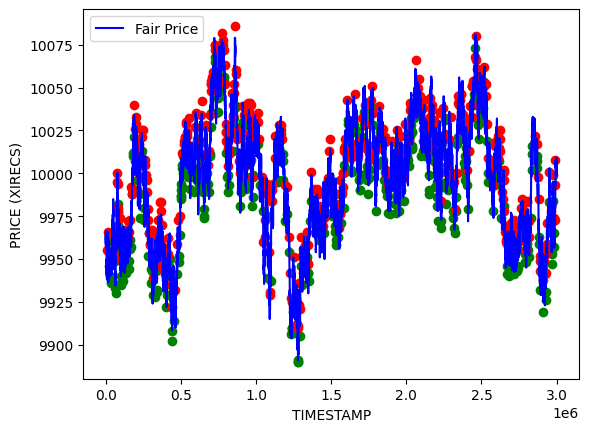

In [150]:
#id scanning

curr_trader_id = "Mark 14"
symbol_n = "HYDROGEL_PACK"
hydro_bid_price = df.loc[df['product']==symbol_n]["bid_price_1"].to_numpy()
hydro_ask_price = df.loc[df['product']==symbol_n]["ask_price_1"].to_numpy()
hydro_mid_price = df.loc[df['product']==symbol_n]["mid_price"].to_numpy().astype(float)

#plt.plot([i*100 for i in range(len(hydro_bid_price))], hydro_bid_price, color="green", label="Best Bid")
#plt.plot([i*100 for i in range(len(hydro_ask_price))], hydro_ask_price, color="red", label="Lowest Ask")
plt.plot([i*100 for i in range(len(hydro_bid_price))], hydro_mid_price, color="blue", label="Fair Price")
plt.scatter(traders_by_symbol[symbol_n][curr_trader_id]["buys_timestamp"], traders_by_symbol[symbol_n][curr_trader_id]["buys"], color="green")
plt.scatter(traders_by_symbol[symbol_n][curr_trader_id]["sells_timestamp"], traders_by_symbol[symbol_n][curr_trader_id]["sells"], color="red")

#plt.plot(midrange_line, color="purple", linewidth=2, label="Decaying Midrange")

plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

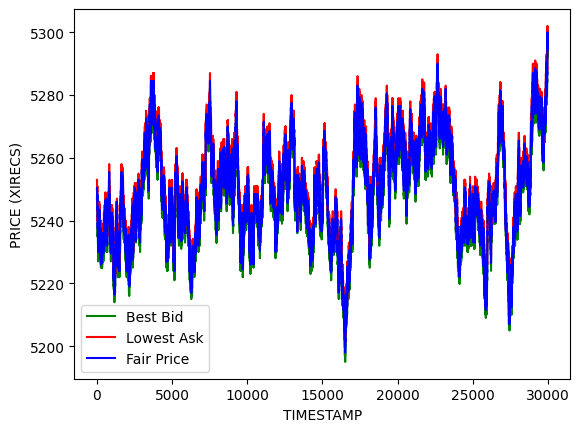

In [104]:
#extract RESEARCH

extract_bid_price = df.loc[df['product']=="VELVETFRUIT_EXTRACT"]["bid_price_1"].to_numpy()
extract_ask_price = df.loc[df['product']=="VELVETFRUIT_EXTRACT"]["ask_price_1"].to_numpy()
extract_mid_price = df.loc[df['product']=="VELVETFRUIT_EXTRACT"]["mid_price"].to_numpy().astype(float)

plt.plot([i for i in range(len(hydro_bid_price))], extract_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(hydro_ask_price))], extract_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(hydro_bid_price))], extract_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

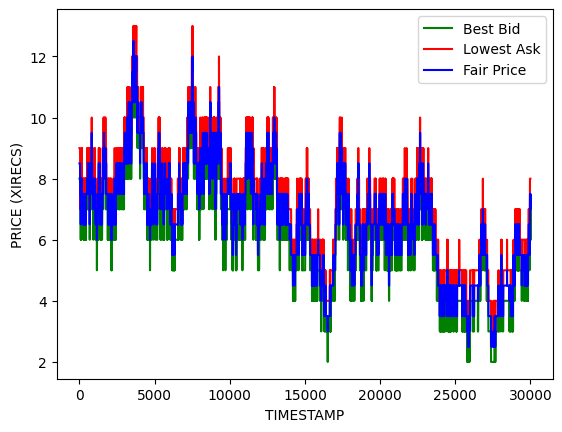

In [188]:
contract_n="VEV_5500"

vev_bid_price = df.loc[df['product']==contract_n]["bid_price_1"].to_numpy()
vev_ask_price = df.loc[df['product']==contract_n]["ask_price_1"].to_numpy()
vev_mid_price = df.loc[df['product']==contract_n]["mid_price"].to_numpy().astype(float)

plt.plot([i for i in range(len(vev_bid_price))], vev_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(vev_bid_price))], vev_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(vev_bid_price))], vev_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

In [ ]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List
from statistics import NormalDist
import numpy as np

class Trader:
    def __init__(self):
        self.alpha = 0.1
        self.vouchers = ['VEV_4000', 'VEV_4500',
            'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
            'VEV_6000', 'VEV_6500']
        self.strikes = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]

    # --- Kalman Step ---
    def kalman_step(self, z, state_dict,
                    process_var=1e-6,
                    measurement_var=25.0,
                    kappa=0.05):

        if "kf_x" not in self.state_dict:
            self.trader_state["kf_x"] = [z, 0.0]
            self.trader_state["kf_P"] = [[1.0, 0.0], [0.0, 1.0]]

        x = np.array(self.trader_state["kf_x"])
        P = np.array(self.trader_state["kf_P"])

        F = np.array([
            [1, 0],
            [0, (1 - kappa)]
        ])

        H = np.array([[1, 1]])

        Q = np.array([
            [process_var, 0],
            [0, process_var]
        ])

        R = np.array([[measurement_var]])

        # Predict
        x = F @ x
        P = F @ P @ F.T + Q

        # Update
        y = np.array([z]) - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)

        x = x + (K @ y).flatten()
        P = (np.eye(2) - K @ H) @ P

        self.trader_state["kf_x"] = x.tolist()
        self.trader_state["kf_P"] = P.tolist()

        return x[0], x[1]  # trend, residual

    # --- HYDROGEL STRATEGY (UPGRADED) ---
    def hydrogel_strategy(self, state: TradingState):
        symbol = "HYDROGEL_PACK"
        LIMIT = 200
        ORDER_SIZE = 20

        if len(state.order_depths[symbol].buy_orders) == 0 or len(state.order_depths[symbol].sell_orders) == 0:
            return

        best_bid = max(state.order_depths[symbol].buy_orders)
        best_ask = min(state.order_depths[symbol].sell_orders)
        mid = (best_bid + best_ask) / 2
        position = state.position.get(symbol, 0)

        # --- Kalman Filter ---
        trend, residual = self.kalman_step(mid, self.trader_state)

        # --- Residual normalization (lightweight) ---
        if "res_hist" not in self.trader_state:
            self.trader_state["res_hist"] = []

        res_hist = self.trader_state["res_hist"]
        res_hist.append(residual)
        if len(res_hist) > 50:
            res_hist.pop(0)

        sigma = np.std(res_hist) if len(res_hist) > 10 else 1.0
        if sigma < 1e-6:
            sigma = 1.0

        z = residual / sigma

        # --- Fair value = Kalman trend ---
        fair = trend

        # --- Edge skew (THIS is key) ---
        skew = 0
        if z > 1.5:
            skew = -1  # lean sell
        elif z < -1.5:
            skew = 1   # lean buy

        # --- Quote around fair ---
        spread = max(1, (best_ask - best_bid) // 2)

        bid_quote = best_bid+1 + skew
        ask_quote = best_ask-1 + skew

        # --- Inventory control ---
        buy_size = min(ORDER_SIZE, LIMIT - position)
        sell_size = min(ORDER_SIZE, LIMIT + position)

        if bid_quote < fair :
            self.result[symbol].append(Order(symbol, bid_quote, buy_size))

        if ask_quote > fair:
            self.result[symbol].append(Order(symbol, ask_quote, -sell_size))
    def trade_hydrogel_linreg(self, state: TradingState):
        symbol = "HYDROGEL_PACK"
        LIMIT = 200
        ORDER_SIZE = 20
        WINDOW = 50

        if len(state.order_depths[symbol].buy_orders) == 0 or len(state.order_depths[symbol].sell_orders) == 0:
            return

        best_bid = max(state.order_depths[symbol].buy_orders)
        best_ask = min(state.order_depths[symbol].sell_orders)
        mid = (best_bid + best_ask) / 2
        position = state.position.get(symbol, 0)

        # --- Store price history ---
        if "linreg_hist" not in self.trader_state:
            self.trader_state["linreg_hist"] = []

        hist = self.trader_state["linreg_hist"]
        hist.append(mid)

        if len(hist) > WINDOW:
            hist.pop(0)

        if len(hist) < 10:
            return  # not enough data

        # --- Linear regression ---
        y = np.array(hist)
        x = np.arange(len(y))

        x_mean = np.mean(x)
        y_mean = np.mean(y)

        # slope and intercept
        slope = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
        intercept = y_mean - slope * x_mean

        # predicted current fair value
        fair = slope * x[-1] + intercept

        # --- Residual ---
        residual = mid - fair

        # --- Normalize residual ---
        if "linreg_res_hist" not in self.trader_state:
            self.trader_state["linreg_res_hist"] = []

        res_hist = self.trader_state["linreg_res_hist"]
        res_hist.append(residual)

        if len(res_hist) > 50:
            res_hist.pop(0)

        sigma = np.std(res_hist) if len(res_hist) > 10 else 1.0
        if sigma < 1e-6:
            sigma = 1.0

        z = residual / sigma

        # --- Trading thresholds ---
        ENTRY_Z = 3
        EXIT_Z = 0.5

        # --- Mean reversion trades ---
        if z < -ENTRY_Z:
            available = LIMIT - position
            if available > 0:
                qty = min(ORDER_SIZE, available)
                self.result[symbol].append(Order(symbol, best_ask, qty))

        elif z > ENTRY_Z:
            available = LIMIT + position
            if available > 0:
                qty = min(ORDER_SIZE, available)
                self.result[symbol].append(Order(symbol, best_bid, -qty))

        # --- Optional exit logic ---
        
    def copy_trader(self, state: TradingState, symbol: str, trader_id: str):
        if symbol not in state.market_trades:
            return
        for trade in state.market_trades[symbol]:
            if trade.seller == trader_id:
                self.result[symbol].append(Order(symbol, int(trade.price), 10))
            elif trade.buyer == trader_id:
                self.result[symbol].append(Order(symbol, int(trade.price), -10))

    def reset(self):
        self.result = {}
        self.result["HYDROGEL_PACK"] = []
        self.result["VELVETFRUIT_EXTRACT"] = []
        for voucher_n in self.vouchers:
            self.result[voucher_n] = []

    def run(self, state: TradingState):
        self.reset()

        if state.traderData and state.traderData != "":
            self.trader_state = json.loads(state.traderData)
        else:
            self.trader_state = {}

        #self.hydrogel_strategy(state)
        self.trade_hydrogel_linreg(state)
        return self.result, 0, json.dumps(self.trader_state)

In [8]:
backtesting_engine = Backtester(prices_files, trades_files)

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [70]:
sample_trader = Trader()
#backtesting_engine.custom_shifter["TOMATOES"]=1.5
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=False, enable_market_trades=True)

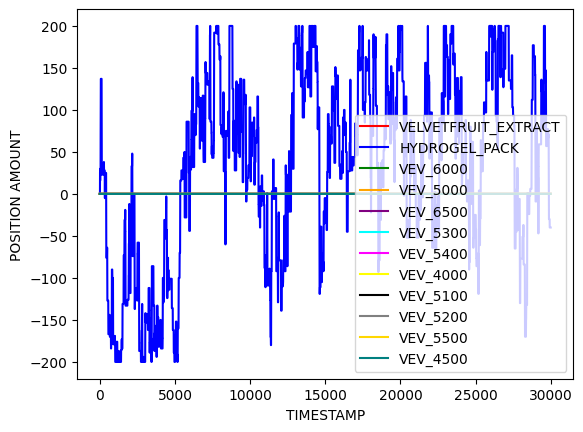

In [66]:
backtesting_result.graph_inventory()

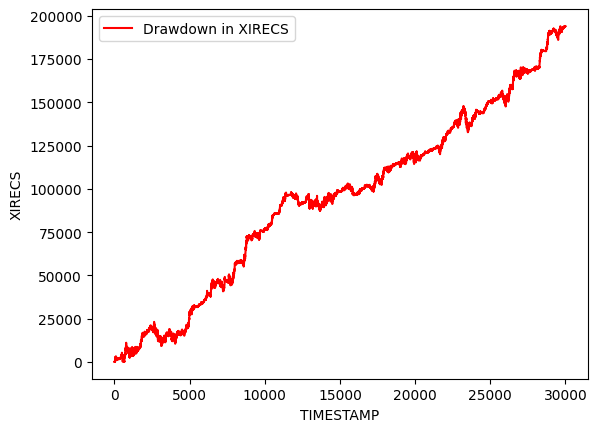

In [67]:
backtesting_result.graph_drawdown()

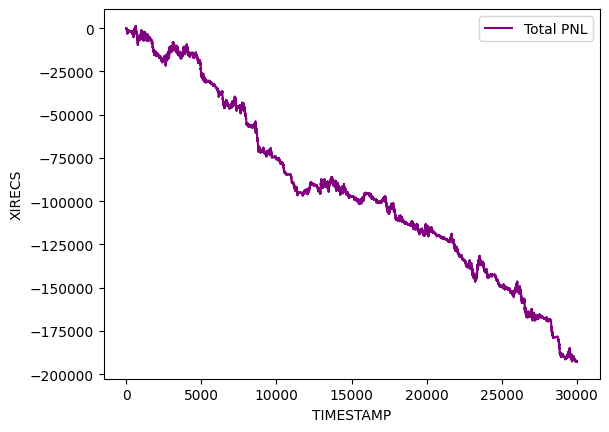

In [68]:
backtesting_result.graph_pnl()